<span style="color:#888888">Copyright (c) 2014-2021 National Technology and Engineering Solutions of Sandia, LLC. Under the terms of Contract DE-NA0003525 with National Technology and Engineering Solutions of Sandia, LLC, the U.S. Government retains certain rights in this software.     Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:</span>

<span style="color:#888888">1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.</span>

<span style="color:#888888">2. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution.</span>

<span style="color:#888888">THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.</span>

## <span style="color:#0054a8">**Tutorial 5-B:**</span> <span style="color:#555555">Static Trajectory Visualization</span>

**Purpose**: If consistency across renders and exports is a requirement, static rendering may be preferred over interactive rendering. 

In [1]:
import tracktable.examples.tutorials.tutorial_helper as tutorial 

### Let's start with a list of trajectories.

We will use the provided example data $^1$ for this tutorial.  For brevity, the function below reads our trajectories from a .traj file into a python list, as was demoed in [Tutorial 4](Tutorial_04.ipynb).

In [2]:
trajectories = tutorial.get_trajectory_list('tutorial-static-viz')

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


Let's work with 15 trajectories so that our visualizaitons render quickly. 

In [3]:
fifteen_trajectories = trajectories[60:75]

In [4]:
from tracktable.render import render_map
from tracktable.render.map_processing import paths
import cartopy
import matplotlib
import matplotlib.pyplot as plt

Our static map choices are `conus` (continental United States), `europe`, `north_america`, `south_america`, `australia`, and `world`. These can be passed in as strings appended to `region:` in the `map_name` parameter of the mapmaker function.

A quick note about Jupyter notebooks. Jupyter will show you the state of the figure when you exit the cell in which you created it. You cannot apply different effects in different cells.  To work around this, we put all our different effects in functions, then call those functions one after another in a single cell.

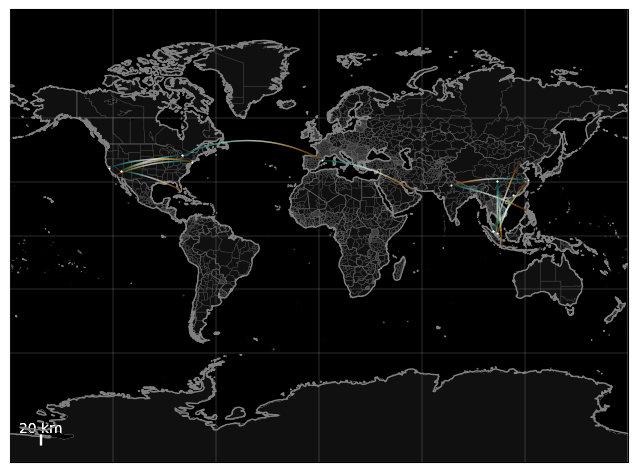

In [5]:
# Set up our canvas to be a 800x600 image (8x6 inches at 100 dpi).
figure = plt.figure(dpi=100, figsize=(8, 6))

# Set up our map projection to be the entire world.
(mymap, map_actors) = render_map.render_map(domain='terrestrial', map_name='region:world')

# Render the trajectories.
paths.draw_traffic(traffic_map=mymap, trajectory_iterable=fifteen_trajectories, transform=cartopy.crs.PlateCarree())

These trajectories are a bit hard to see.  Let's customize our rendering to make the trajectories easier to see:

1. Use `color_map` to get a red heat color.
2. Use `linewidth` to make the lines thicker.
3. Use `dot_size` to make the destination easier to see.
4. Use `transform` to define our cartopy projection.

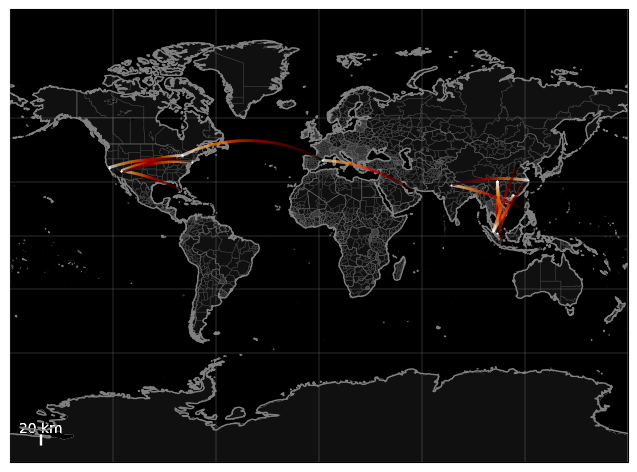

In [6]:
# Set up our canvas to be a 800x600 image (8x6 inches at 100 dpi).
figure = plt.figure(dpi=100, figsize=(8, 6))

# Set up our map projection to be the entire world.
(mymap, map_actors) = render_map.render_map(domain='terrestrial',
                                        map_name='region:world')

# Render the trajectories.
paths.draw_traffic(traffic_map=mymap, 
                   trajectory_iterable=fifteen_trajectories, 
                   color_map="gist_heat",
                   linewidth=2,
                   dot_size=2,
                   transform=cartopy.crs.PlateCarree()
                  )